In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset_Cleaned.xlsx to Dataset_Cleaned.xlsx


In [ ]:
import pandas as pd
df = pd.read_excel("Dataset_Cleaned.xlsx")

print("shape:", df.shape)
print(df.head())

shape: (1200, 14)
     OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023/01/04     C72649  Monitor         5     570.62   
1  ORD200001  2024/08/23     C75739    Phone         2     151.35   
2  ORD200002  2024/02/27     C81728   Tablet         5     550.68   
3  ORD200003  2023/10/15     C33540    Chair         1     273.19   
4  ORD200004  2025/05/08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral     

In [ ]:
print("Missing value:")
print(df.isnull().sum())

Missing value:
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [ ]:
print("Descriptive statistics:")
print(df.describe())

Descriptive statistics:
          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000


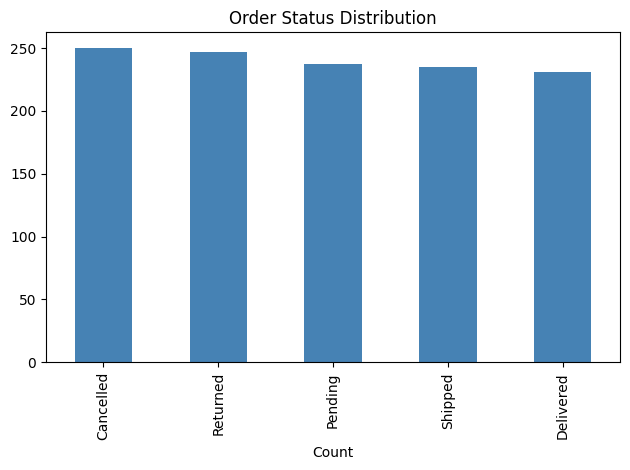

In [ ]:
import matplotlib.pyplot as plt
df['OrderStatus'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Order Status Distribution')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

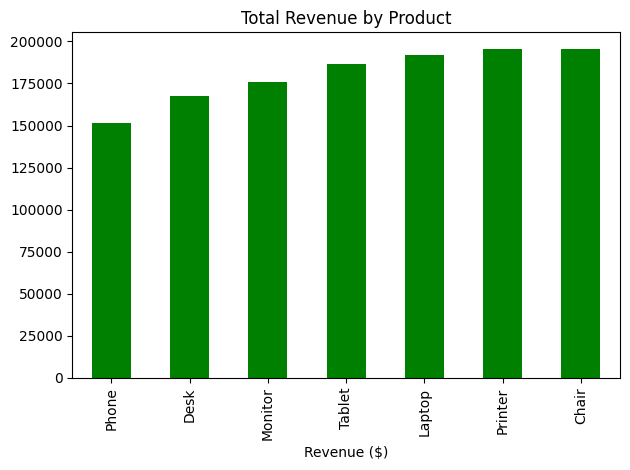

In [ ]:
df.groupby('Product')['TotalPrice'].sum().sort_values().plot(kind='bar', color='green')
plt.title('Total Revenue by Product')
plt.xlabel('Revenue ($)')
plt.tight_layout()
plt.show()

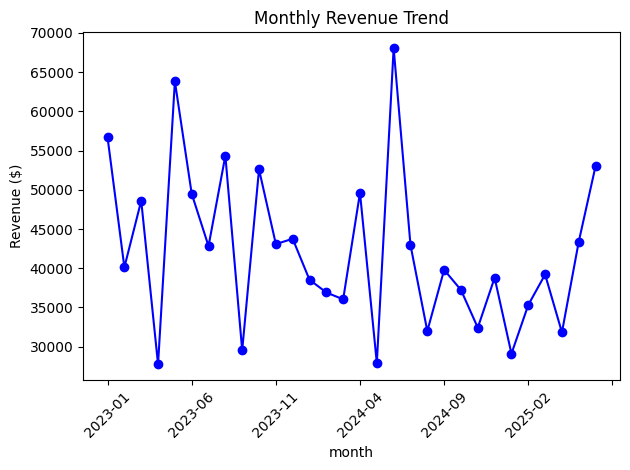

In [ ]:
df['Date']=pd.to_datetime(df['Date'])
df['month']=df['Date'].dt.to_period('M').astype(str)

df.groupby('month')['TotalPrice'].sum().plot(kind='line', marker='o', color='blue')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

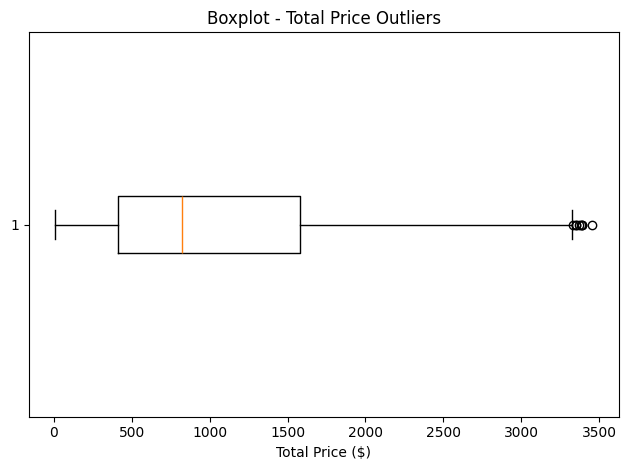

In [ ]:
plt.boxplot(df['TotalPrice'], vert=False)
plt.title('Boxplot - Total Price Outliers')
plt.xlabel('Total Price ($)')
plt.tight_layout()
plt.show()

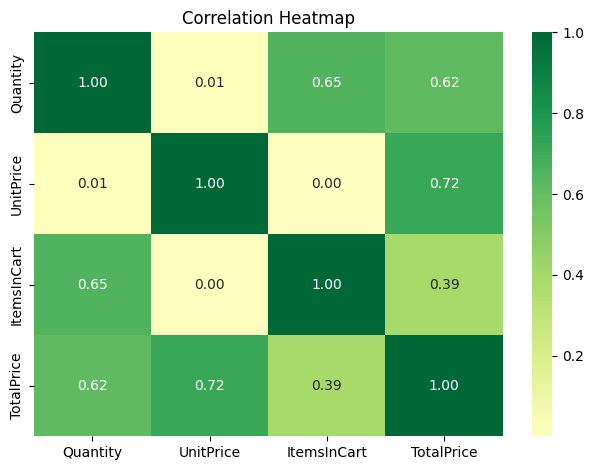

In [ ]:
import seaborn as sns
corr = df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

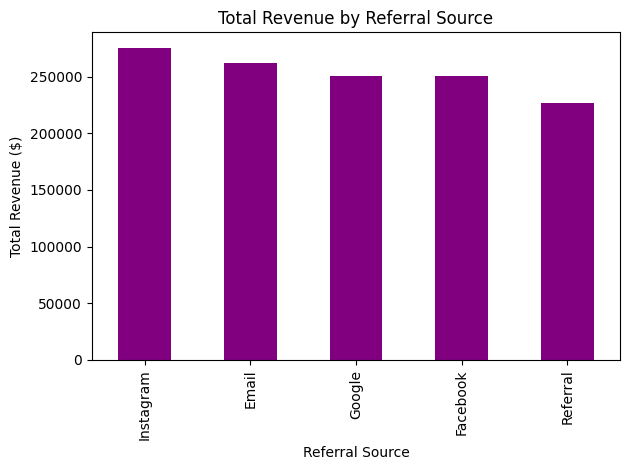

In [ ]:
df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False).plot(kind='bar', color='purple')
plt.title('Total Revenue by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 50)
print("KEY FINDINGS AND OBSERVATIONS")
print("=" * 50)

print("\n1. DATASET OVERVIEW")
print(f"  Total Orders: {len(df)}")
print(f"  Original Columns (before feature engineering): 14")
print(f"  Columns in analyzed DataFrame (after adding 'month'): {len(df.columns)}")

print("\n2. MISSING VALUES")
print(f"  No missing values found in any column.")

print(
"\n3. DESCRIPTIVE STATISTICS")
print(f"    Mean TotalPrice: ${df['TotalPrice'].mean():,.2f}")
print(f"    Median TotalPrice: ${df['TotalPrice'].median():,.2f}")
print(f"    Observation: Mean > Median = Right Skewed Data")

print("\n4. ORDER STATUS")
print(df['OrderStatus'].value_counts())
print(f"  Cancelled + Returned = {((df['OrderStatus'].value_counts().get('Cancelled', 0) + df['OrderStatus'].value_counts().get('Returned', 0)) / len(df) * 100):.1f}% of all orders")

print("\n5. MONTHLY REVENUE TREND")
monthly_revenue = df.groupby('month')['TotalPrice'].sum()
max_revenue_month = monthly_revenue.idxmax()
min_revenue_month = monthly_revenue.idxmin()
print(f"  Revenue fluctuates monthly. Highest revenue in {max_revenue_month}, lowest in {min_revenue_month}.")

print("\n6. TOP PRODUCT BY REVENUE")
top_product = df.groupby('Product')['TotalPrice'].sum().idxmax()
print(f"   {top_product}")

print("\n7. TOP REFERRAL SOURCE")
top_ref_source = df['ReferralSource'].value_counts().idxmax()
print(f"   {top_ref_source} drives the most orders")

print("\n8. OUTLIERS")
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
Outliers = df[(df['TotalPrice'] < Q1 - 1.5 * IQR) |
              (df['TotalPrice'] > Q3 + 1.5 *IQR)]
print(f"  TotalPrice outliers found: {len(Outliers)}")

print("\n9.  CORRELATION")
print(f"    UnitPrice vs TotalPrice: {df[['UnitPrice', 'TotalPrice']].corr().iloc[0, 1]:.2f} (Strong)")
print(f"    Quantity vs TotalPrice: {df[['Quantity', 'TotalPrice']].corr().iloc[0, 1]:.2f} (Moderate)")

print("\n" + "=" * 50)
print("END OF EDA REPORT")
print("=" * 50)

KEY FINDINGS AND OBSERVATIONS

1. DATASET OVERVIEW
  Total Orders: 1200
  Original Columns (before feature engineering): 14
  Columns in analyzed DataFrame (after adding 'month'): 15

2. MISSING VALUES
  No missing values found in any column.

3. DESCRIPTIVE STATISTICS
    Mean TotalPrice: $1,053.97
    Median TotalPrice: $823.62
    Observation: Mean > Median = Right Skewed Data

4. ORDER STATUS
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64
  Cancelled + Returned = 41.4% of all orders

5. MONTHLY REVENUE TREND
  Revenue fluctuates monthly. Highest revenue in 2024-06, lowest in 2023-04.

6. TOP PRODUCT BY REVENUE
   Chair

7. TOP REFERRAL SOURCE
   Instagram drives the most orders

8. OUTLIERS
  TotalPrice outliers found: 8

9.  CORRELATION
    UnitPrice vs TotalPrice: 0.72 (Strong)
    Quantity vs TotalPrice: 0.62 (Moderate)

END OF EDA REPORT


## RECOMMENDATIONS

In [ ]:
print("=" * 50)
print("RECOMMENDATIONS")
print("=" * 50)


print("\n1. Order Status Management:")
print("  - The combined 'Cancelled' and 'Returned' orders account for over 41% of all orders. This is a significant loss and requires immediate attention.")
print("  - Dive deeper into the reasons for cancellations and returns. Is it product quality, shipping issues, customer service, or buyer's remorse? Conduct root cause analysis for both categories.")
print("  - Implement strategies to reduce cancellations (e.g., clearer product descriptions, better inventory management) and returns (e.g., improved sizing guides, enhanced quality control).")

print("\n2. Leverage Top Performers:")
print("  - **Top Product (Chair):** Since 'Chair' is the top revenue-generating product, consider running special promotions, bundles, or marketing campaigns specifically for chairs. Ensure sufficient stock and optimize product pages for this item.")
print("  - **Top Referral Source (Instagram):** Instagram drives the most orders. Allocate more marketing budget and efforts towards Instagram campaigns. Explore different ad formats, influencer collaborations, and engagement strategies on this platform.")

print("\n3. Outlier Analysis for TotalPrice:")
print("  - Investigate the 8 'TotalPrice' outliers. Are these legitimate high-value orders or data entry errors? Understanding these outliers can reveal insights into high-spending customers or identify data quality issues.")
print("  - If legitimate, identify characteristics of these high-value transactions to potentially replicate success (e.g., specific product combinations, customer segments).")

print("\n4. Customer Segmentation (Future Work):")
print("  - With 'CustomerID' available, perform customer segmentation to identify high-value customers, frequent buyers, and at-risk customers. Tailor marketing and retention strategies accordingly.")

print("\n5. Time-Series Forecasting (Future Work):")
print("  - Although only 9 days of data, with more historical data, the monthly revenue trend can be further analyzed for seasonality and growth. This can inform inventory planning and marketing efforts.")


print("\n" + "=" * 50)
print("END OF RECOMMENDATIONS")
print("=" * 50)

RECOMMENDATIONS

1. Order Status Management:
  - The combined 'Cancelled' and 'Returned' orders account for over 41% of all orders. This is a significant loss and requires immediate attention.
  - Dive deeper into the reasons for cancellations and returns. Is it product quality, shipping issues, customer service, or buyer's remorse? Conduct root cause analysis for both categories.
  - Implement strategies to reduce cancellations (e.g., clearer product descriptions, better inventory management) and returns (e.g., improved sizing guides, enhanced quality control).

2. Leverage Top Performers:
  - **Top Product (Chair):** Since 'Chair' is the top revenue-generating product, consider running special promotions, bundles, or marketing campaigns specifically for chairs. Ensure sufficient stock and optimize product pages for this item.
  - **Top Referral Source (Instagram):** Instagram drives the most orders. Allocate more marketing budget and efforts towards Instagram campaigns. Explore diffe